In [1]:
# Part 1 — Load & Explore the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (168, 2)

Columns:
Index(['Date', 'Production'], dtype='object')

Data Types:
Date          object
Production     int64
dtype: object

Missing Values:
Date          0
Production    0
dtype: int64


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


In [6]:
print(df["Production"].describe())

count    168.000000
mean     754.708333
std      102.204524
min      553.000000
25%      677.750000
50%      761.000000
75%      824.500000
max      969.000000
Name: Production, dtype: float64


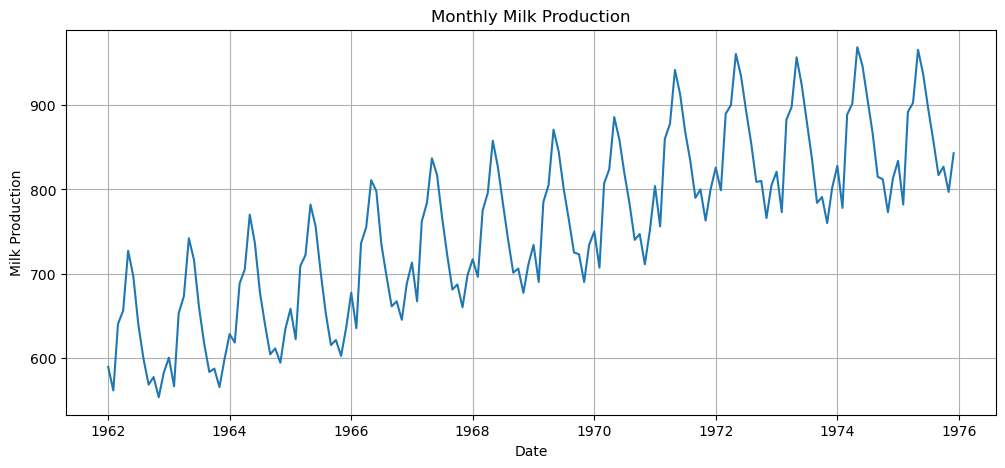

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Production"]
)

plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Milk Production")

plt.grid(True)
plt.show()

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
Q1 = df["Production"].quantile(0.25)
Q3 = df["Production"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Production"] < lower_bound) |
    (df["Production"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print(outliers)

Number of outliers: 0
Empty DataFrame
Columns: [Date, Production]
Index: []


In [ ]:
# EDA Observations:
# The dataset contains 168 monthly milk production records with two variables: Date and Production.

# The Date column was converted into datetime format and the observations were sorted chronologically. The dataset contains no missing values.

# The time-series plot is used to identify the overall production trend, seasonal patterns, and unusual observations. Descriptive statistics and the IQR method are also used to investigate the distribution and possible outliers in milk production.

# The observed temporal structure will be considered when preparing input-output sequences for the RNN, LSTM, and GRU models.

In [10]:
# Part 2 — Scaling & Time-Series Sequence Preparation

data = df["Production"].values.reshape(-1, 1)

print("Data shape:", data.shape)

Data shape: (168, 1)


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

print("Minimum:", scaled_data.min())
print("Maximum:", scaled_data.max())

Minimum: 0.0
Maximum: 1.0000000000000002


In [12]:
n = len(scaled_data)

train_size = int(n * 0.70)
val_size = int(n * 0.15)

print("Total:", n)
print("Training:", train_size)
print("Validation:", val_size)
print("Test:", n - train_size - val_size)

Total: 168
Training: 117
Validation: 25
Test: 26


In [13]:
train_data = data[:train_size]

val_data = data[train_size:train_size + val_size]

test_data = data[
    train_size + val_size:
]

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

Train: (117, 1)
Validation: (25, 1)
Test: (26, 1)


In [14]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)

val_scaled = scaler.transform(val_data)

test_scaled = scaler.transform(test_data)

In [16]:
window_size = 12

In [17]:
def create_sequences(data, window_size):
    
    X = []
    y = []
    
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    
    return np.array(X), np.array(y)

In [18]:
X_train, y_train = create_sequences(
    train_scaled,
    window_size
)

X_val, y_val = create_sequences(
    val_scaled,
    window_size
)

X_test, y_test = create_sequences(
    test_scaled,
    window_size
)

In [19]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (105, 12, 1)
y_train: (105, 1)
X_val: (13, 12, 1)
y_val: (13, 1)
X_test: (14, 12, 1)
y_test: (14, 1)


In [ ]:
# Data Preparation for Deep Learning:
# The milk production data was divided chronologically into training, validation, and test sets to preserve the temporal order of the observations.

# Min-Max scaling was applied to normalize the production values to a range between 0 and 1. The scaler was fitted only on the training data to prevent information from the validation and test periods from leaking into the training process.

# A 12-month sliding window was selected to create input-output sequences. Each input sequence contains the previous 12 months of milk production, while the corresponding target represents production for the following month.

# The resulting three-dimensional input structure is suitable for RNN, LSTM, and GRU models.

In [20]:
# Part 3 — Build the Basic RNN

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam

In [21]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [22]:
rnn_model = Sequential([
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(window_size, 1)
    ),
    
    Dense(1)
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

rnn_model.summary()

C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0542 - val_loss: 0.0125
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0152 - val_loss: 0.0600
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0129 - val_loss: 0.0115
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0077 - val_loss: 0.0090
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0059 - val_loss: 0.0148
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0053 - val_loss: 0.0094
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0048 - val_loss: 0.0066
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0037 - val_loss: 0.0082
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0039 - val_loss: 0.0066
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0033 - val_loss: 0.0044
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0029 - val_loss: 0.0054
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0028 - val_l

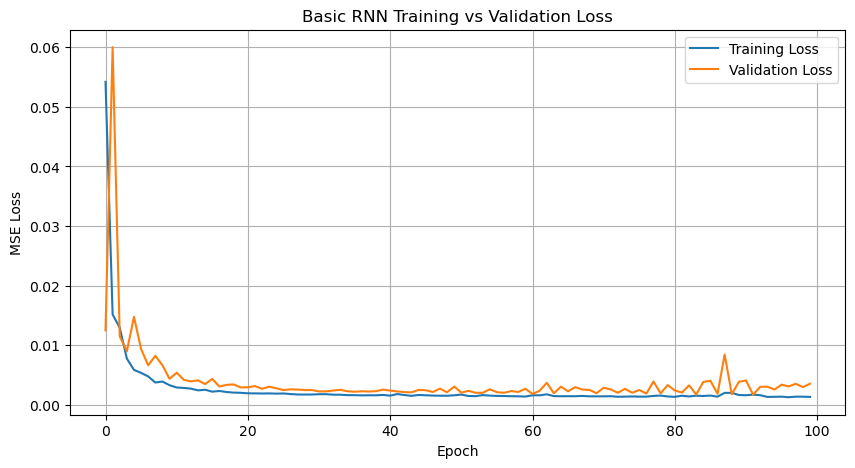

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("Basic RNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
rnn_pred_scaled = rnn_model.predict(
    X_test
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


In [26]:
rnn_pred = scaler.inverse_transform(
    rnn_pred_scaled
)

y_test_actual = scaler.inverse_transform(
    y_test
)

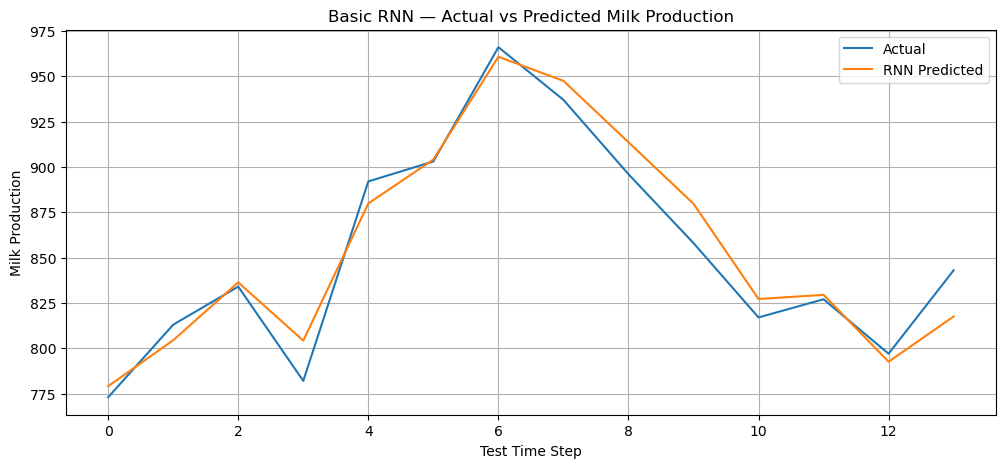

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    rnn_pred,
    label="RNN Predicted"
)

plt.title("Basic RNN — Actual vs Predicted Milk Production")
plt.xlabel("Test Time Step")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_rnn = np.sqrt(
    mean_squared_error(
        y_test_actual,
        rnn_pred
    )
)

mae_rnn = mean_absolute_error(
    y_test_actual,
    rnn_pred
)

mape_rnn = np.mean(
    np.abs(
        (y_test_actual - rnn_pred) /
        y_test_actual
    )
) * 100

print("RNN Performance")
print("----------------")
print("RMSE:", rmse_rnn)
print("MAE :", mae_rnn)
print("MAPE:", mape_rnn, "%")

RNN Performance
----------------
RMSE: 13.239509170260204
MAE : 10.712367466517874
MAPE: 1.2654213058416348 %


In [ ]:
# Basic RNN Model:
# A basic Recurrent Neural Network (RNN) was developed to forecast monthly milk production. The model uses a 12-month historical window as input and predicts the production value for the following month.

# The model consists of a SimpleRNN layer followed by a Dense output layer. The Adam optimizer and Mean Squared Error (MSE) loss function were used for training.

# # The model was trained using the training sequences while validation data was used to monitor its performance during training. Predictions were converted back to the original production scale and evaluated using RMSE, MAE, and MAPE.

In [29]:
# Part 4 — Build the LSTM Model

from tensorflow.keras.layers import LSTM

In [30]:
lstm_model = Sequential([
    LSTM(
        50,
        activation="tanh",
        input_shape=(window_size, 1)
    ),
    
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

lstm_model.summary()

C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.1997 - val_loss: 0.2706
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0798 - val_loss: 0.0555
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0319 - val_loss: 0.0484
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0390 - val_loss: 0.0295
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0312 - val_loss: 0.0394
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0318 - val_loss: 0.0362
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0298 - val_loss: 0.0289
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0286 - val_loss: 0.0276
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0287 - val_loss: 0.0277
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0280 - val_loss: 0.0272
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0275 - val_loss: 0.0266
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0273 - val_l

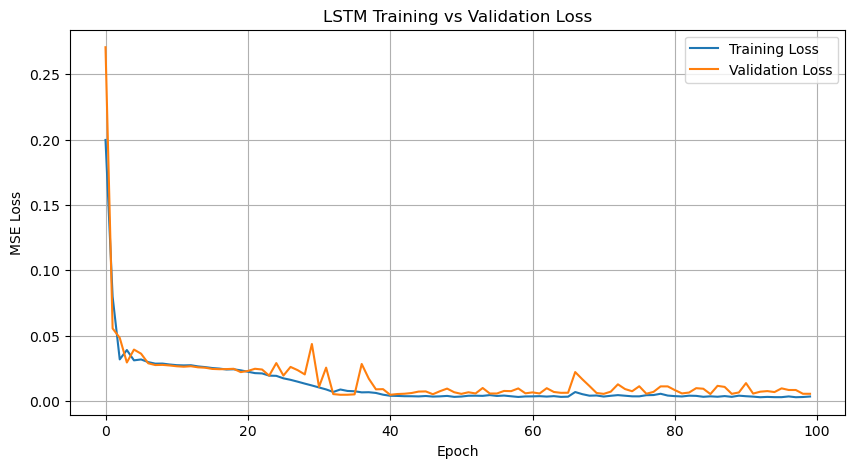

In [32]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
lstm_pred_scaled = lstm_model.predict(
    X_test
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step


In [34]:
lstm_pred = scaler.inverse_transform(
    lstm_pred_scaled
)

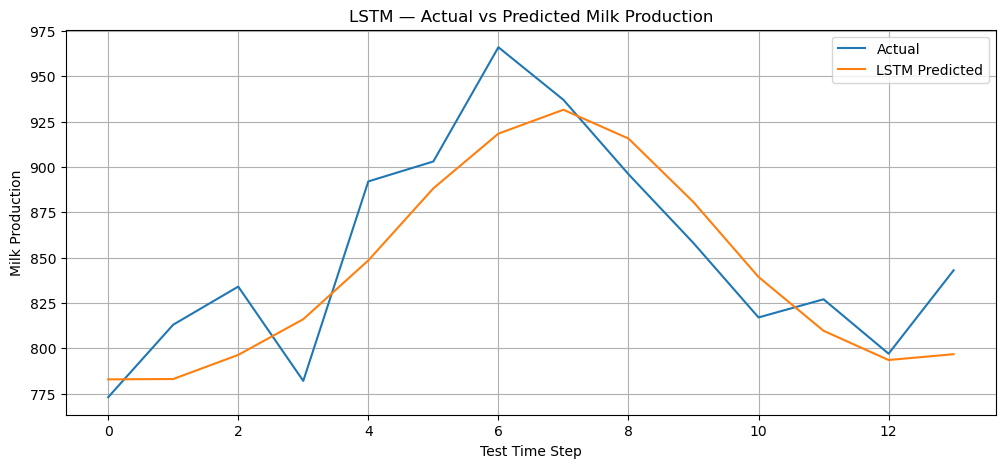

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    lstm_pred,
    label="LSTM Predicted"
)

plt.title("LSTM — Actual vs Predicted Milk Production")
plt.xlabel("Test Time Step")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_actual,
        lstm_pred
    )
)

mae_lstm = mean_absolute_error(
    y_test_actual,
    lstm_pred
)

mape_lstm = np.mean(
    np.abs(
        (y_test_actual - lstm_pred) /
        y_test_actual
    )
) * 100

print("LSTM Performance")
print("-----------------")
print("RMSE:", rmse_lstm)
print("MAE :", mae_lstm)
print("MAPE:", mape_lstm, "%")

LSTM Performance
-----------------
RMSE: 29.078995560394702
MAE : 25.335344587053573
MAPE: 2.9609237607927446 %


In [ ]:
# LSTM Model:
# A Long Short-Term Memory (LSTM) network was developed for monthly milk production forecasting. LSTM is a recurrent neural network architecture designed to learn dependencies in sequential data.

# The LSTM receives the previous 12 months of production as input and predicts the following month's production. The model was trained using the training data and monitored using the validation set.

# The predictions were converted back to the original production scale and evaluated using RMSE, MAE, and MAPE.

In [37]:
# Part 5 — Build the GRU Model

from tensorflow.keras.layers import GRU

In [38]:
gru_model = Sequential([
    GRU(
        50,
        activation="tanh",
        input_shape=(window_size, 1)
    ),
    
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

gru_model.summary()

C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - loss: 0.1920 - val_loss: 0.2533
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0696 - val_loss: 0.0660
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0332 - val_loss: 0.0296
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0398 - val_loss: 0.0285
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0325 - val_loss: 0.0373
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0301 - val_loss: 0.0492
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0296 - val_loss: 0.0435
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0277 - val_loss: 0.0361
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0271 - val_loss: 0.0290
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0269 - val_loss: 0.0288
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0259 - val_loss: 0.0308
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0250 - val_l

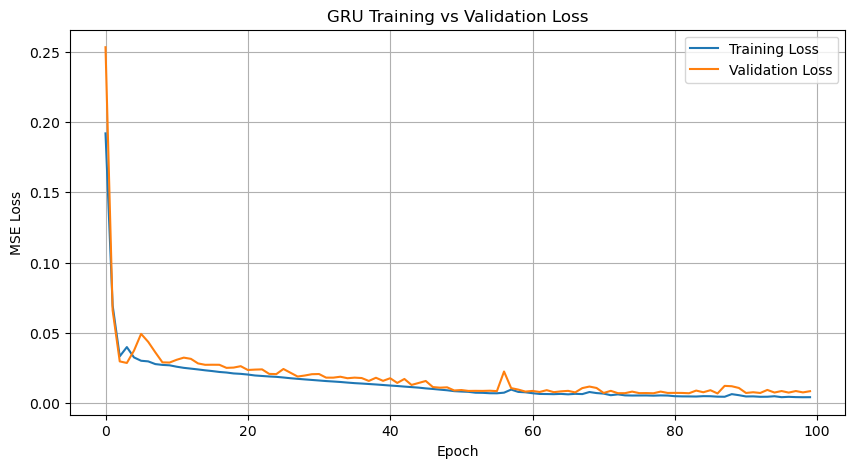

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
gru_pred_scaled = gru_model.predict(
    X_test
)

gru_pred = scaler.inverse_transform(
    gru_pred_scaled
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


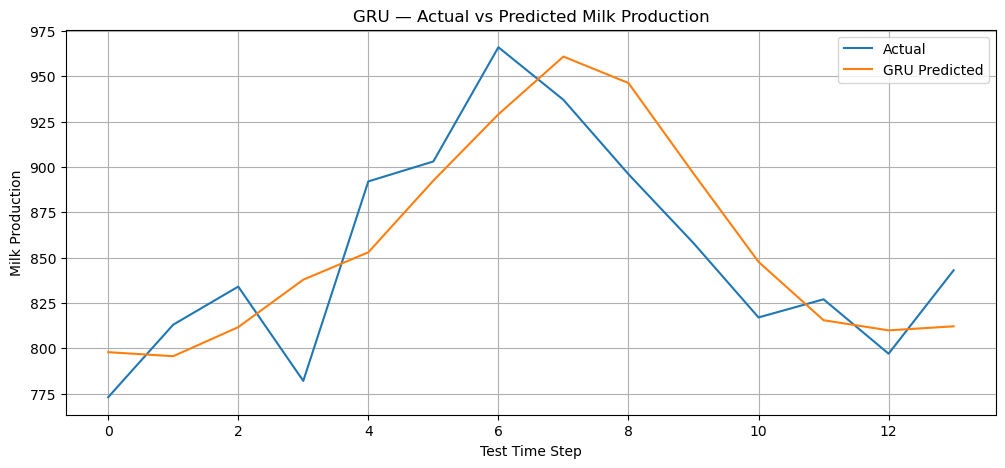

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    gru_pred,
    label="GRU Predicted"
)

plt.title("GRU — Actual vs Predicted Milk Production")
plt.xlabel("Test Time Step")
plt.ylabel("Milk Production")
plt.legend()
plt.grid(True)

plt.show()

In [43]:
rmse_gru = np.sqrt(
    mean_squared_error(
        y_test_actual,
        gru_pred
    )
)

mae_gru = mean_absolute_error(
    y_test_actual,
    gru_pred
)

mape_gru = np.mean(
    np.abs(
        (y_test_actual - gru_pred) /
        y_test_actual
    )
) * 100

print("GRU Performance")
print("----------------")
print("RMSE:", rmse_gru)
print("MAE :", mae_gru)
print("MAPE:", mape_gru, "%")

GRU Performance
----------------
RMSE: 31.967451047737768
MAE : 28.96552821568082
MAPE: 3.4006775417115755 %


In [ ]:
# GRU Model:
# A Gated Recurrent Unit (GRU) network was developed to forecast monthly milk production.

# The GRU uses the previous 12 months of production as input and predicts the following month's production. The model was trained using the training sequences, while the validation data was used to monitor model performance.

# The predictions were transformed back to the original production scale and evaluated using RMSE, MAE, and MAPE.

In [44]:
# Part 6 — Compare RNN, LSTM, and GRU

model_comparison = pd.DataFrame({
    "Model": [
        "Basic RNN",
        "LSTM",
        "GRU"
    ],
    "RMSE": [
        rmse_rnn,
        rmse_lstm,
        rmse_gru
    ],
    "MAE": [
        mae_rnn,
        mae_lstm,
        mae_gru
    ],
    "MAPE (%)": [
        mape_rnn,
        mape_lstm,
        mape_gru
    ]
})

model_comparison

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,13.239509,10.712367,1.265421
1,LSTM,29.078996,25.335345,2.960924
2,GRU,31.967451,28.965528,3.400678


In [45]:
model_comparison = pd.DataFrame({
    "Model": [
        "Basic RNN",
        "LSTM",
        "GRU"
    ],
    "RMSE": [
        rmse_rnn,
        rmse_lstm,
        rmse_gru
    ],
    "MAE": [
        mae_rnn,
        mae_lstm,
        mae_gru
    ],
    "MAPE (%)": [
        mape_rnn,
        mape_lstm,
        mape_gru
    ]
})

model_comparison

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,13.239509,10.712367,1.265421
1,LSTM,29.078996,25.335345,2.960924
2,GRU,31.967451,28.965528,3.400678


In [46]:
best_rmse_model = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

best_mae_model = model_comparison.loc[
    model_comparison["MAE"].idxmin(),
    "Model"
]

best_mape_model = model_comparison.loc[
    model_comparison["MAPE (%)"].idxmin(),
    "Model"
]

print("Best RMSE:", best_rmse_model)
print("Best MAE :", best_mae_model)
print("Best MAPE:", best_mape_model)

Best RMSE: Basic RNN
Best MAE : Basic RNN
Best MAPE: Basic RNN


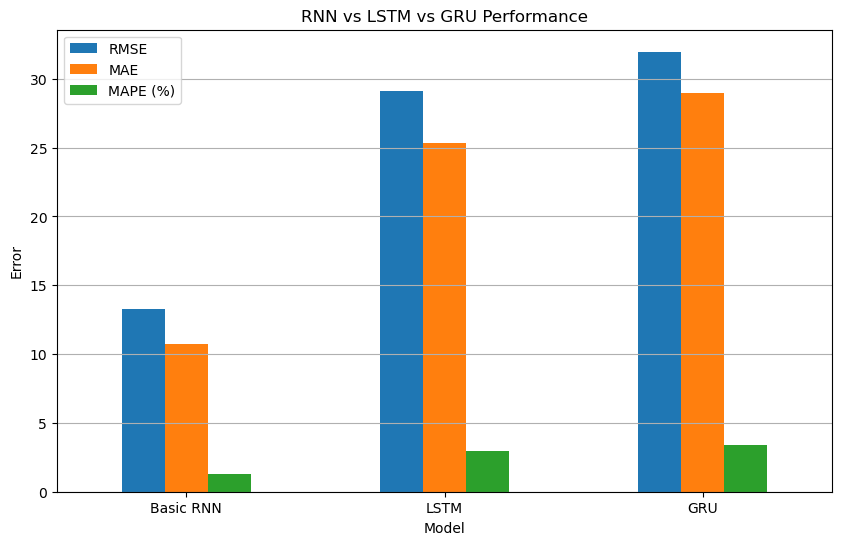

In [47]:
model_comparison.set_index("Model")[
    ["RMSE", "MAE", "MAPE (%)"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("RNN vs LSTM vs GRU Performance")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

In [ ]:
# Model Comparison:
# The Basic RNN, LSTM, and GRU models were evaluated using RMSE, MAE, and MAPE.

# RMSE measures the square root of the average squared prediction error, while MAE measures the average absolute prediction error. MAPE expresses the prediction error as a percentage of the actual values.

# For all three metrics, lower values indicate better forecasting performance. The model comparison table and visualization are used to identify the model that provides the most accurate predictions on the test dataset.

# The best-performing model is selected based on its overall forecasting error across the evaluation metrics.

In [48]:
# Part 7 — Hyperparameter Tuning

best_model_name = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

print("Best architecture based on RMSE:", best_model_name)

Best architecture based on RMSE: Basic RNN


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam


def build_model(
    model_type,
    units=50,
    learning_rate=0.001
):
    
    model = Sequential()
    
    if model_type == "Basic RNN":
        model.add(
            SimpleRNN(
                units,
                activation="tanh",
                input_shape=(window_size, 1)
            )
        )
        
    elif model_type == "LSTM":
        model.add(
            LSTM(
                units,
                activation="tanh",
                input_shape=(window_size, 1)
            )
        )
        
    elif model_type == "GRU":
        model.add(
            GRU(
                units,
                activation="tanh",
                input_shape=(window_size, 1)
            )
        )
    
    model.add(Dense(1))
    
    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="mse"
    )
    
    return model

In [50]:
param_grid = [
    {"units": 32, "learning_rate": 0.001},
    {"units": 32, "learning_rate": 0.0005},
    {"units": 64, "learning_rate": 0.001},
    {"units": 64, "learning_rate": 0.0005}
]

batch_size = 16
epochs = 100

In [51]:
tuning_results = []

for params in param_grid:
    
    print("Testing:", params)
    
    tuned_model = build_model(
        model_type=best_model_name,
        units=params["units"],
        learning_rate=params["learning_rate"]
    )
    
    history = tuned_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    
    val_loss = min(
        history.history["val_loss"]
    )
    
    tuning_results.append({
        "Units": params["units"],
        "Learning Rate": params["learning_rate"],
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Validation Loss": val_loss
    })

Testing: {'units': 32, 'learning_rate': 0.001}


C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Testing: {'units': 32, 'learning_rate': 0.0005}
Testing: {'units': 64, 'learning_rate': 0.001}
Testing: {'units': 64, 'learning_rate': 0.0005}


In [52]:
tuning_df = pd.DataFrame(
    tuning_results
)

tuning_df = tuning_df.sort_values(
    "Validation Loss"
).reset_index(drop=True)

tuning_df

,Units,Learning Rate,Batch Size,Epochs,Validation Loss
0,64,0.0010,16,100,0.001711
1,32,0.0010,16,100,0.002321
2,64,0.0005,16,100,0.002477
3,32,0.0005,16,100,0.003069


In [53]:
best_params = tuning_df.iloc[0]

print("Best Hyperparameters:")
print(best_params)

Best Hyperparameters:
Units               64.000000
Learning Rate        0.001000
Batch Size          16.000000
Epochs             100.000000
Validation Loss      0.001711
Name: 0, dtype: float64


In [54]:
final_model = build_model(
    model_type=best_model_name,
    units=int(best_params["Units"]),
    learning_rate=float(
        best_params["Learning Rate"]
    )
)

final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=int(best_params["Epochs"]),
    batch_size=int(best_params["Batch Size"]),
    verbose=1
)

Epoch 1/100


C:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - loss: 0.1066 - val_loss: 0.0197
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0193 - val_loss: 0.1002
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0207 - val_loss: 0.0173
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0080 - val_loss: 0.0058
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0044 - val_loss: 0.0190
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0044 - val_loss: 0.0091
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0026 - val_loss: 0.0039
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0026 - val_loss: 0.0064
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0024 - val_loss: 0.0050
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0020 - val_loss: 0.0045
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0021 - val_loss: 0.0036


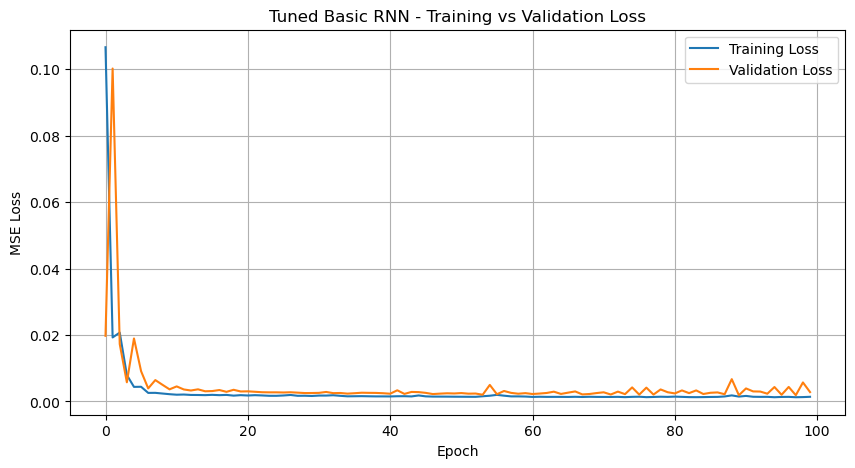

In [55]:
plt.figure(figsize=(10, 5))

plt.plot(
    final_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    final_history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    f"Tuned {best_model_name} - Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
# Hyperparameter Tuning:
# Hyperparameter tuning was performed on the best-performing recurrent architecture identified during the initial model comparison.

# The number of hidden units and learning rate were varied systematically across multiple configurations. A validation dataset was used to compare the configurations and select the model with the lowest validation loss.

# The selected configuration was then retrained using the training data and evaluated on the unseen test set. This approach helps determine whether modifying the training configuration can improve forecasting performance while reducing the risk of overfitting.

In [57]:
# Part 8 — Evaluate the Tuned Model

final_pred_scaled = final_model.predict(X_test)

final_pred = scaler.inverse_transform(
    final_pred_scaled
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step


In [58]:
rmse_final = np.sqrt(
    mean_squared_error(
        y_test_actual,
        final_pred
    )
)

mae_final = mean_absolute_error(
    y_test_actual,
    final_pred
)

mape_final = np.mean(
    np.abs(
        (y_test_actual - final_pred) /
        y_test_actual
    )
) * 100

print("Tuned Model Performance")
print("------------------------")
print("RMSE:", rmse_final)
print("MAE :", mae_final)
print("MAPE:", mape_final, "%")

Tuned Model Performance
------------------------
RMSE: 13.217894885828718
MAE : 10.829350062779017
MAPE: 1.2769673268194628 %


In [59]:
final_comparison = pd.DataFrame({
    "Model": [
        "Basic RNN",
        "LSTM",
        "GRU",
        f"Tuned {best_model_name}"
    ],
    "RMSE": [
        rmse_rnn,
        rmse_lstm,
        rmse_gru,
        rmse_final
    ],
    "MAE": [
        mae_rnn,
        mae_lstm,
        mae_gru,
        mae_final
    ],
    "MAPE (%)": [
        mape_rnn,
        mape_lstm,
        mape_gru,
        mape_final
    ]
})

final_comparison

,Model,RMSE,MAE,MAPE (%)
0,Basic RNN,13.239509,10.712367,1.265421
1,LSTM,29.078996,25.335345,2.960924
2,GRU,31.967451,28.965528,3.400678
3,Tuned Basic RNN,13.217895,10.829350,1.276967


In [60]:
best_final_model = final_comparison.loc[
    final_comparison["RMSE"].idxmin(),
    "Model"
]

print("Final Best Model:", best_final_model)

Final Best Model: Tuned Basic RNN


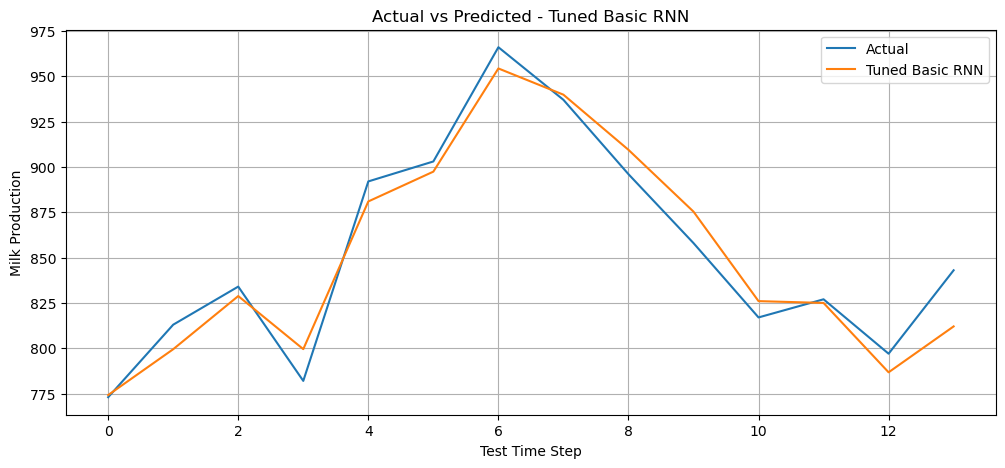

In [61]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    final_pred,
    label=f"Tuned {best_model_name}"
)

plt.title(
    f"Actual vs Predicted - Tuned {best_model_name}"
)

plt.xlabel("Test Time Step")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Tuned Model Evaluation:
# The selected hyperparameter configuration was evaluated on the unseen test dataset.

# RMSE, MAE, and MAPE were calculated using predictions transformed back to the original milk-production scale. The tuned model was then compared with the original Basic RNN, LSTM, and GRU models.

# The model with the lowest forecasting error is considered the best-performing model for this dataset. The final evaluation is performed only after hyperparameter selection to maintain a clear separation between validation and test data.

In [62]:
# Part 9 — 12-Month Future Forecast

last_12_months = scaler.transform(
    data[-window_size:]
)
current_sequence = last_12_months.reshape(1, window_size, 1)

print("Input shape:", current_sequence.shape)

Input shape: (1, 12, 1)


In [63]:
future_predictions_scaled = []

for i in range(12):

    next_prediction = final_model.predict(
        current_sequence,
        verbose=0
    )

    future_predictions_scaled.append(
        next_prediction[0, 0]
    )

    current_sequence = np.concatenate(
        [
            current_sequence[:, 1:, :],
            next_prediction.reshape(1, 1, 1)
        ],
        axis=1
    )

print("Number of predictions:", len(future_predictions_scaled))
print(future_predictions_scaled)

Number of predictions: 12
[np.float32(0.7341493), np.float32(0.6473594), np.float32(0.85403794), np.float32(0.8877014), np.float32(1.0192094), np.float32(0.969863), np.float32(0.89409703), np.float32(0.8157059), np.float32(0.71739674), np.float32(0.735062), np.float32(0.65534914), np.float32(0.7319279)]


In [64]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
).flatten()

print("Future predictions:")
print(future_predictions)

Future predictions:
[838.58405 804.8228  885.2207  898.3158  949.4725  930.27673 900.8037
 870.3096  832.0674  838.9391  807.9308  837.72   ]


In [65]:
last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Production": future_predictions
})

forecast_df

,Date,Forecasted Production
0,1976-01-01,838.584045
1,1976-02-01,804.822815
2,1976-03-01,885.220703
3,1976-04-01,898.315796
4,1976-05-01,949.472473
5,1976-06-01,930.276733
6,1976-07-01,900.803711
7,1976-08-01,870.309570
8,1976-09-01,832.067383
9,1976-10-01,838.939087


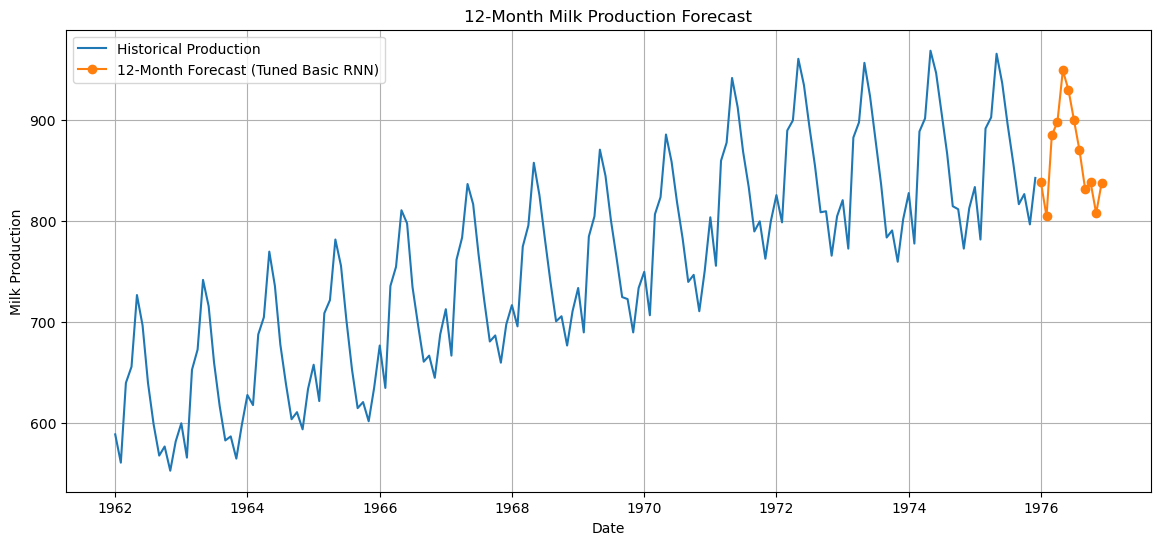

In [66]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted Production"],
    marker="o",
    label=f"12-Month Forecast ({best_final_model})"
)

plt.title("12-Month Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Milk Production")

plt.legend()
plt.grid(True)

plt.show()

In [67]:
# Part 10 — Business Insights & Final Conclusion

forecast_df["Change"] = (
    forecast_df["Forecasted Production"].diff()
)

forecast_df

,Date,Forecasted Production,Change
0,1976-01-01,838.584045,NaN
1,1976-02-01,804.822815,-33.761230
2,1976-03-01,885.220703,80.397888
3,1976-04-01,898.315796,13.095093
4,1976-05-01,949.472473,51.156677
5,1976-06-01,930.276733,-19.195740
6,1976-07-01,900.803711,-29.473022
7,1976-08-01,870.309570,-30.494141
8,1976-09-01,832.067383,-38.242188
9,1976-10-01,838.939087,6.871704


In [68]:
first_forecast = forecast_df[
    "Forecasted Production"
].iloc[0]

last_forecast = forecast_df[
    "Forecasted Production"
].iloc[-1]

percentage_change = (
    (last_forecast - first_forecast)
    / first_forecast
) * 100

print(
    "Forecast change:",
    round(percentage_change, 2),
    "%"
)

Forecast change: -0.1 %


In [69]:
max_row = forecast_df.loc[
    forecast_df["Forecasted Production"].idxmax()
]

min_row = forecast_df.loc[
    forecast_df["Forecasted Production"].idxmin()
]

print(
    "Highest forecast:",
    max_row["Date"],
    "->",
    round(max_row["Forecasted Production"], 2)
)

print(
    "Lowest forecast:",
    min_row["Date"],
    "->",
    round(min_row["Forecasted Production"], 2)
)

Highest forecast: 1976-05-01 00:00:00 -> 949.47
Lowest forecast: 1976-02-01 00:00:00 -> 804.82


In [ ]:
# Business Insights and Recommendations:
# The 12-month forecast provides an estimate of future milk production and can support operational and production planning decisions.

In [ ]:
# Key Insights:
# Production Planning Forecasted production can help management estimate future production levels and prepare operational plans accordingly.

# Resource Allocation Expected changes in production can help with planning feed, labor, storage, transportation, and other operational resources.

# Inventory Management Forecast information can support better planning of storage capacity and inventory requirements.

# Capacity Planning Periods with relatively higher predicted production may require additional processing or storage capacity.

# Demand and Supply Planning Forecasts can be compared with expected demand to identify potential periods of surplus or insufficient production.

In [ ]:
# Limitations:
# The forecasts are model-based estimates and should not be treated as guaranteed production values. Because the 12-month forecast is generated recursively, prediction errors can accumulate over longer forecasting horizons.

# The model also uses historical milk production as the primary input, so external factors such as weather, feed availability, livestock health, market conditions, and operational changes are not explicitly represented.

# Therefore, the forecasts should be combined with domain knowledge and other relevant business information when making decisions.

In [ ]:
# Final Conclusion:
# This project developed a deep learning-based time-series forecasting system for monthly milk production.

# The historical production data was explored and prepared using chronological train, validation, and test splits. Min-Max scaling and a 12-month sliding window were used to prepare the sequential data for deep learning.

# Three recurrent neural network architectures were developed: Basic RNN, LSTM, and GRU. Their forecasting performance was evaluated using RMSE, MAE, and MAPE.

# Hyperparameter tuning was then performed on the best-performing architecture to investigate whether changes in the number of hidden units and learning rate could improve forecasting performance.

# Finally, the selected tuned model was used to generate a 12-month future forecast. The forecast can support production planning, resource allocation, inventory management, and capacity planning.

# Although the model provides useful forecasting information, its predictions are subject to uncertainty and should be interpreted alongside external business factors and domain knowledge.